In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import os

In [113]:
import os
import pandas as pd


csv_path = '../../data/ultimate_student_productivity_dataset_5000.csv'

print(f"Loading data from: {csv_path}")

try:
    df = pd.read_csv(csv_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"File not found at: {os.path.abspath(csv_path)}")
    print(f"Current working directory is: {os.getcwd()}")

    raise

print(f"Original shape: {df.shape}")

Loading data from: ../../data/ultimate_student_productivity_dataset_5000.csv
Data loaded successfully.
Original shape: (5000, 21)


In [114]:
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [115]:
df.shape

(5000, 21)

In [116]:
df.columns

Index(['student_id', 'age', 'gender', 'academic_level', 'study_hours',
       'self_study_hours', 'online_classes_hours', 'social_media_hours',
       'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'internet_quality', 'mental_health_score', 'focus_index',
       'burnout_level', 'productivity_score', 'exam_score'],
      dtype='str')

In [117]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   str    
 3   academic_level        5000 non-null   str    
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality      5000 non-n

1. Understand the problem (choose target)
2. Drop obviously useless / harmful columns
   - IDs
   - leakage columns
3. Focus only on remaining columns
4. Check missing values
5. Handle missing values
6. Encode categorical features
7. (Optional) Scale features
8. Train model


In [118]:
df.describe()

,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,20.520400,4.539594,2.478734,2.011984,2.998086,1.564514,7.016492,6.979588,74.535600,251.450400,0.498200,0.501400,5.507400,29.431616,45.615324,37.267716,18.803752
std,1443.520003,2.870406,1.821665,1.177990,0.983906,1.467949,1.110807,1.163692,2.486214,42.932293,143.842712,0.500047,0.500048,2.869145,9.962902,14.246591,16.849397,12.130840
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1250.750000,18.000000,3.250000,1.660000,1.320000,1.990000,0.670000,6.237500,5.280000,37.000000,129.000000,0.000000,0.000000,3.000000,22.567500,35.727500,25.290000,9.337500
50%,2500.500000,20.000000,4.530000,2.480000,2.010000,2.980000,1.490000,7.010000,6.950000,75.000000,252.000000,0.000000,1.000000,5.000000,29.430000,45.690000,36.860000,18.010000
75%,3750.250000,23.000000,5.760000,3.290000,2.690000,4.030000,2.340000,7.810000,8.710000,112.000000,376.000000,1.000000,1.000000,8.000000,36.242500,55.352500,49.142500,27.400000
max,5000.000000,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,149.000000,499.000000,1.000000,1.000000,10.000000,63.480000,97.580000,98.020000,64.090000


In [119]:
df = df.drop(columns=['student_id', 'age', 'gender'])


In [120]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   academic_level        5000 non-null   str    
 1   study_hours           5000 non-null   float64
 2   self_study_hours      5000 non-null   float64
 3   online_classes_hours  5000 non-null   float64
 4   social_media_hours    5000 non-null   float64
 5   gaming_hours          5000 non-null   float64
 6   sleep_hours           5000 non-null   float64
 7   screen_time_hours     5000 non-null   float64
 8   exercise_minutes      5000 non-null   int64  
 9   caffeine_intake_mg    5000 non-null   int64  
 10  part_time_job         5000 non-null   int64  
 11  upcoming_deadline     5000 non-null   int64  
 12  internet_quality      5000 non-null   str    
 13  mental_health_score   5000 non-null   int64  
 14  focus_index           5000 non-null   float64
 15  burnout_level         5000 non-n

In [121]:
df.head()

,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,High School,7.64,1.56,2.20,3.05,2.19,6.52,6.47,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,High School,2.21,2.22,2.10,1.65,2.55,5.97,6.05,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,High School,3.45,0.00,0.29,1.34,2.08,8.39,7.62,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,High School,5.75,2.08,3.01,2.27,2.20,6.31,11.67,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,High School,6.83,1.72,3.33,2.65,0.70,8.01,10.02,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [122]:
df.tail()

,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
4995,Undergraduate,3.93,1.42,0.54,2.58,2.62,9.30,6.38,113,496,0,0,Good,9,35.55,33.24,48.83,22.51
4996,High School,4.00,0.00,3.00,4.45,2.47,6.42,7.32,146,411,0,1,Poor,5,16.87,59.07,23.32,2.00
4997,Undergraduate,5.63,2.52,2.89,3.58,1.07,6.65,9.51,123,306,0,1,Good,7,23.85,47.72,41.09,27.89
4998,Undergraduate,3.58,2.83,1.53,5.88,1.28,7.36,8.31,54,304,1,1,Good,4,13.04,58.90,12.62,3.63
4999,Undergraduate,5.60,4.14,2.17,3.05,2.74,6.38,9.59,24,219,0,1,Good,3,29.98,61.01,34.72,10.76


# Now we will delete the lekage columns 
A leakage column is any feature that contains information that would not be available at the time you want to make a prediction, often because it is an outcome or a derived summary related to the target.

in our dataset:-
| Column              | Known before exam? | Keep?      |
| ------------------- | ------------------ | ---------- |
| study_hours         | ✅ Yes              | ✅ Keep     |
| sleep_hours         | ✅ Yes              | ✅ Keep     |
| screen_time         | ✅ Yes              | ✅ Keep     |
| mental_health_score | ⚠️ Maybe           | ⚠️ Depends |
| focus_index         | ❌ No               | ❌ Drop     |
| productivity_score  | ❌ No               | ❌ Drop     |
| burnout_level       | ❌ No               | ❌ Drop     |
| exam_score          | ❌ No (target)      | 🎯 Target  |


In [123]:
df = df.drop(columns=[
    'focus_index',
    'burnout_level',
    'productivity_score'
])


In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   academic_level        5000 non-null   str    
 1   study_hours           5000 non-null   float64
 2   self_study_hours      5000 non-null   float64
 3   online_classes_hours  5000 non-null   float64
 4   social_media_hours    5000 non-null   float64
 5   gaming_hours          5000 non-null   float64
 6   sleep_hours           5000 non-null   float64
 7   screen_time_hours     5000 non-null   float64
 8   exercise_minutes      5000 non-null   int64  
 9   caffeine_intake_mg    5000 non-null   int64  
 10  part_time_job         5000 non-null   int64  
 11  upcoming_deadline     5000 non-null   int64  
 12  internet_quality      5000 non-null   str    
 13  mental_health_score   5000 non-null   int64  
 14  exam_score            5000 non-null   float64
dtypes: float64(8), int64(5), str(2)


In [125]:
df.head()

,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,exam_score
0,High School,7.64,1.56,2.20,3.05,2.19,6.52,6.47,81,38,1,0,Good,10,50.16
1,High School,2.21,2.22,2.10,1.65,2.55,5.97,6.05,111,339,0,0,Good,3,1.00
2,High School,3.45,0.00,0.29,1.34,2.08,8.39,7.62,68,266,0,1,Good,8,18.30
3,High School,5.75,2.08,3.01,2.27,2.20,6.31,11.67,113,480,1,1,Poor,3,9.37
4,High School,6.83,1.72,3.33,2.65,0.70,8.01,10.02,121,24,1,0,Good,8,27.81


In [126]:
df.tail()

,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,exam_score
4995,Undergraduate,3.93,1.42,0.54,2.58,2.62,9.30,6.38,113,496,0,0,Good,9,22.51
4996,High School,4.00,0.00,3.00,4.45,2.47,6.42,7.32,146,411,0,1,Poor,5,2.00
4997,Undergraduate,5.63,2.52,2.89,3.58,1.07,6.65,9.51,123,306,0,1,Good,7,27.89
4998,Undergraduate,3.58,2.83,1.53,5.88,1.28,7.36,8.31,54,304,1,1,Good,4,3.63
4999,Undergraduate,5.60,4.14,2.17,3.05,2.74,6.38,9.59,24,219,0,1,Good,3,10.76


In [127]:
df['internet_quality'].value_counts()


internet_quality
Good       1722
Poor       1640
Average    1638
Name: count, dtype: int64

In [128]:
df['academic_level'].value_counts()

academic_level
Postgraduate     1687
High School      1672
Undergraduate    1641
Name: count, dtype: int64

In [129]:
df['internet_quality'] = df['internet_quality'].str.lower().str.strip()

df['internet_quality'] = df['internet_quality'].map({
    'poor': 0,
    'average': 1,
    'good': 2
})


In [130]:
df.head(10)

,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,exam_score
0,High School,7.64,1.56,2.20,3.05,2.19,6.52,6.47,81,38,1,0,2,10,50.16
1,High School,2.21,2.22,2.10,1.65,2.55,5.97,6.05,111,339,0,0,2,3,1.00
2,High School,3.45,0.00,0.29,1.34,2.08,8.39,7.62,68,266,0,1,2,8,18.30
3,High School,5.75,2.08,3.01,2.27,2.20,6.31,11.67,113,480,1,1,0,3,9.37
4,High School,6.83,1.72,3.33,2.65,0.70,8.01,10.02,121,24,1,0,2,8,27.81
5,Undergraduate,2.21,3.50,1.69,4.47,1.56,8.34,8.06,110,288,0,1,1,8,18.53
6,High School,4.60,2.37,1.27,3.12,1.89,7.61,11.34,19,123,1,1,0,6,10.35
7,High School,8.77,3.78,2.09,1.76,3.13,7.62,7.27,135,379,1,0,2,1,19.89
8,Undergraduate,6.60,0.84,1.00,4.39,0.85,8.29,8.24,101,308,1,0,1,10,30.73
9,High School,3.98,0.16,1.29,3.20,2.13,5.43,7.79,142,415,1,0,1,9,8.99


In [131]:
df['academic_level'] = df['academic_level'].str.lower().str.strip()

df['academic_level'] = df['academic_level'].map({
    'high school': 0,
    'undergraduate': 1,
    'postgraduate': 2
})

In [132]:
df.head(10)

,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,exam_score
0,0,7.64,1.56,2.20,3.05,2.19,6.52,6.47,81,38,1,0,2,10,50.16
1,0,2.21,2.22,2.10,1.65,2.55,5.97,6.05,111,339,0,0,2,3,1.00
2,0,3.45,0.00,0.29,1.34,2.08,8.39,7.62,68,266,0,1,2,8,18.30
3,0,5.75,2.08,3.01,2.27,2.20,6.31,11.67,113,480,1,1,0,3,9.37
4,0,6.83,1.72,3.33,2.65,0.70,8.01,10.02,121,24,1,0,2,8,27.81
5,1,2.21,3.50,1.69,4.47,1.56,8.34,8.06,110,288,0,1,1,8,18.53
6,0,4.60,2.37,1.27,3.12,1.89,7.61,11.34,19,123,1,1,0,6,10.35
7,0,8.77,3.78,2.09,1.76,3.13,7.62,7.27,135,379,1,0,2,1,19.89
8,1,6.60,0.84,1.00,4.39,0.85,8.29,8.24,101,308,1,0,1,10,30.73
9,0,3.98,0.16,1.29,3.20,2.13,5.43,7.79,142,415,1,0,1,9,8.99


In [133]:
df.tail(10)

,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,exam_score
4990,1,5.54,3.07,0.40,5.26,0.00,7.56,5.29,118,184,1,1,2,7,25.25
4991,2,1.82,2.93,2.24,3.32,1.69,6.79,8.20,30,105,1,1,2,8,11.91
4992,2,3.23,3.45,1.10,2.61,0.00,7.10,5.69,99,285,1,0,2,3,15.14
4993,1,3.45,1.97,1.17,3.62,1.27,5.87,4.17,56,9,0,0,2,1,1.00
4994,0,2.48,3.65,2.15,4.39,1.96,5.34,10.11,86,245,0,0,2,10,26.31
4995,1,3.93,1.42,0.54,2.58,2.62,9.30,6.38,113,496,0,0,2,9,22.51
4996,0,4.00,0.00,3.00,4.45,2.47,6.42,7.32,146,411,0,1,0,5,2.00
4997,1,5.63,2.52,2.89,3.58,1.07,6.65,9.51,123,306,0,1,2,7,27.89
4998,1,3.58,2.83,1.53,5.88,1.28,7.36,8.31,54,304,1,1,2,4,3.63
4999,1,5.60,4.14,2.17,3.05,2.74,6.38,9.59,24,219,0,1,2,3,10.76


In [134]:
df[['internet_quality', 'academic_level']].isnull().sum()
df[['internet_quality', 'academic_level']].value_counts()


internet_quality  academic_level
2                 2                 580
                  0                 574
                  1                 568
0                 2                 556
1                 0                 555
                  2                 551
0                 0                 543
                  1                 541
1                 1                 532
Name: count, dtype: int64

In [135]:
df.columns


Index(['academic_level', 'study_hours', 'self_study_hours',
       'online_classes_hours', 'social_media_hours', 'gaming_hours',
       'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'internet_quality', 'mental_health_score', 'exam_score'],
      dtype='str')

#We did all the data analysis and pre processing, now we will be training the model.

In [136]:
X = df.drop('exam_score', axis=1)
y = df['exam_score']


In [146]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# We will be using the Student Performance dataset to predict the exam score of a student based on various features. Using the LinearRegession Algorithm.

In [138]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [139]:
y_pred = model.predict(X_test)


In [140]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE: 5.057810939782998
MSE: 39.89549028175744
RMSE: 6.316287697829908
R² Score: 0.7072105727521572


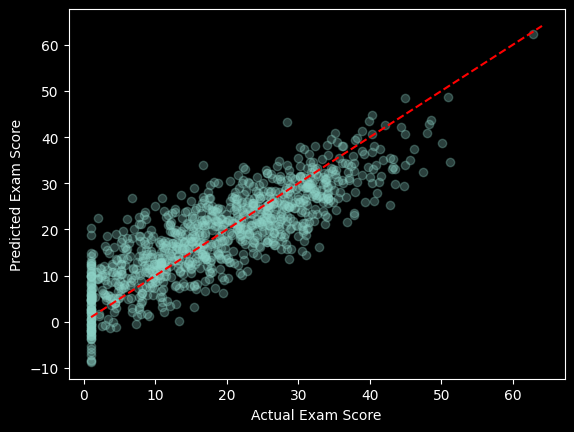

In [141]:

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()


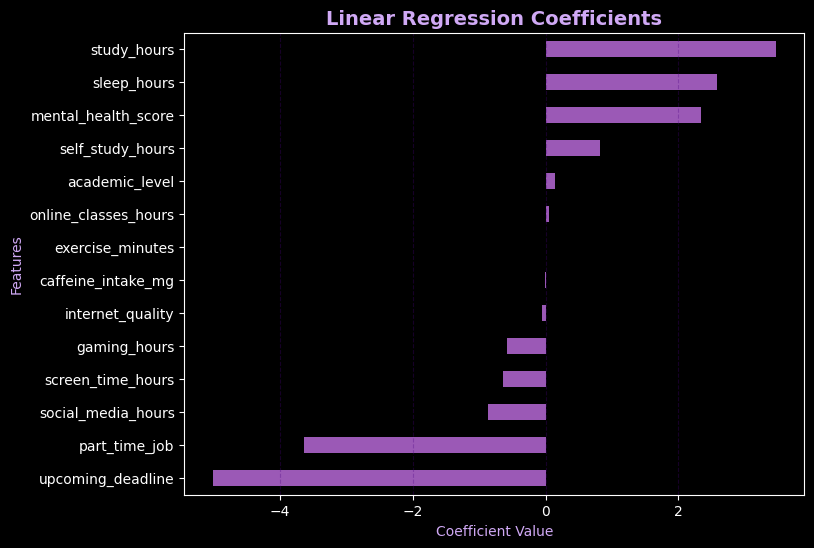

In [142]:

plt.style.use('dark_background')
coeffs = pd.Series(model.coef_, index=X.columns)

ax = coeffs.sort_values().plot(kind='barh', figsize=(8,6), color='#9b59b6')


plt.title("Linear Regression Coefficients", color='#d0a9f5', fontsize=14, fontweight='bold')
plt.xlabel("Coefficient Value", color='#d0a9f5')
plt.ylabel("Features", color='#d0a9f5')

plt.grid(axis='x', linestyle='--', alpha=0.3, color='#4b0082')

plt.show()

In [143]:
df.columns 


Index(['academic_level', 'study_hours', 'self_study_hours',
       'online_classes_hours', 'social_media_hours', 'gaming_hours',
       'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'internet_quality', 'mental_health_score', 'exam_score'],
      dtype='str')

Very low linear contribution (CANDIDATES TO DROP)

These are nearly zero:

online_classes_hours

exercise_minutes

caffeine_intake_mg

internet_quality

We will drop this features and again check the linear contribution.

In [144]:
# drop_cols = [
#     'online_classes_hours',
#     'exercise_minutes',
#     'caffeine_intake_mg',
#     'internet_quality'
# ]

# df_reduced = df.drop(columns=drop_cols)


In [145]:
df_reduced.head()


NameError: name 'df_reduced' is not defined

In [ ]:
# df = df_reduced


In [ ]:
# df.columns 

In [ ]:
# X = df.drop('exam_score', axis=1)
# y = df['exam_score']


In [ ]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )


In [ ]:
from sklearn.linear_model import LinearRegression

model_reduced = LinearRegression()
model_reduced.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# y_pred_reduced = model_reduced.predict(X_test)

# mae = mean_absolute_error(y_test, y_pred_reduced)
# mse = mean_squared_error(y_test, y_pred_reduced)
# rmse = mse ** 0.5
# r2 = r2_score(y_test, y_pred_reduced)

# print("REDUCED LINEAR REGRESSION RESULTS")
# print("MAE:", mae)
# print("RMSE:", rmse)
# print("R²:", r2)


# From dropping those columns,

COMPARISON: BASELINE vs REDUCED MODEL

 Baseline (all features)
MAE ≈ 5.06
RMSE ≈ 6.32
R² ≈ 0.707

Reduced feature model

MAE ≈ 5.15 (worse)
RMSE ≈ 6.40 (worse)
R² ≈ 0.699 (worse)

VERDICT

 Performance dropped slightly
No gain in accuracy
 No stability improvement

So:

Dropping those features hurt the model, even if only a little.

That means:

Those features do carry information
Even if their linear coefficients were small
They helped reduce noise / bias indirectly
This is a very common and very important result.

# WHAT IS THE CORRECT NEXT MOVE?
 Switch algorithm (THIS IS THE RIGHT TIME)

Specifically:

 Random Forest Regressor

Why this is the correct next step now:

Handles many features well

Automatically ignores weak ones

Captures non-linearity

No need to manually drop features

Very robust for tabular data like this

In [ ]:
X = df.drop('exam_score', axis=1)
y = df['exam_score']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
y_pred_rf = rf_model.predict(X_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2 = r2_score(y_test, y_pred_rf)

print("RANDOM FOREST RESULTS")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


RANDOM FOREST RESULTS
MAE: 5.430985049999999
RMSE: 6.7536953849390855
R²: 0.6652546748242939


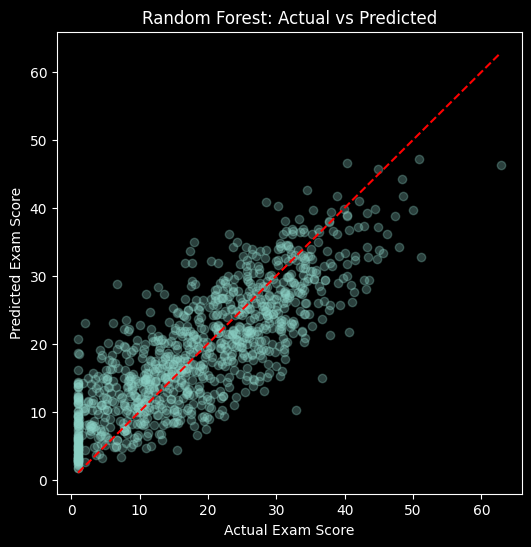

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.show()


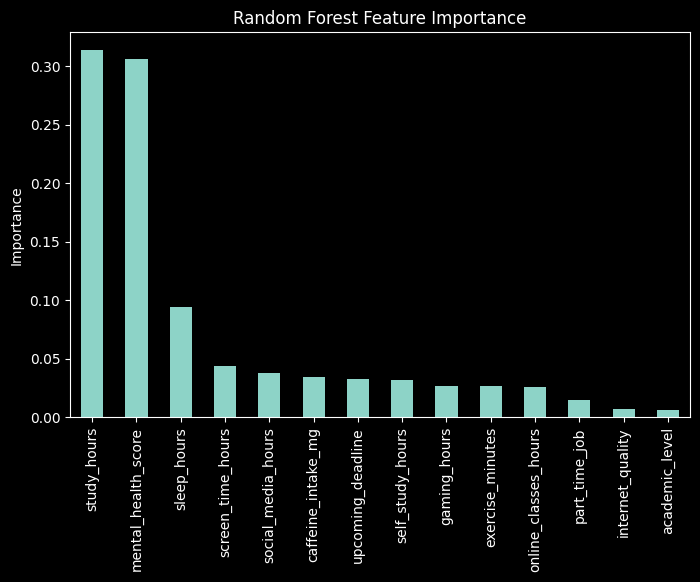

In [ ]:
import pandas as pd

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind='bar')
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.show()



# 📘 Student Exam Score Prediction  
## Data Preprocessing, Model Evaluation, and Insights

---

## 1. Project Objective

The objective of this project is to build and evaluate machine learning models that predict **student exam scores** based on lifestyle habits, academic behavior, and mental health indicators.

The project emphasizes:
- Proper data preprocessing
- Prevention of data leakage
- Building a strong baseline model
- Comparing linear and non-linear algorithms
- Interpreting model performance scientifically

---

## 2. Dataset Overview

- **Dataset name:** `ultimate_student_productivity_dataset_5000.csv`
- **Number of records:** 5,000 students
- **Original features:** 21 columns
- **Target variable:** `exam_score`

The dataset contains information related to:
- Study patterns
- Digital activity
- Health and lifestyle habits
- Academic background

---

## 3. Data Loading

The dataset was loaded into a pandas DataFrame.

```python
df = pd.read_csv("ultimate_student_productivity_dataset_5000.csv")
````

Initial inspection using `df.info()` and `df.describe()` confirmed:

* No missing values in the raw dataset
* A mix of numerical and categorical features
* Multiple outcome-related variables

---

## 4. Initial Data Cleaning and Feature Removal

### 4.1 Dropping Irrelevant Features

The following columns were removed:

| Column       | Reason                                            |
| ------------ | ------------------------------------------------- |
| `student_id` | Identifier only, no predictive value              |
| `age`        | Temporarily removed to simplify baseline modeling |
| `gender`     | Dropped to reduce bias and noise                  |

This ensured the model learned only from behaviorally meaningful features.

---

## 5. Leakage Prevention

### 5.1 Understanding Data Leakage

**Data leakage** occurs when features contain information that would not be available at prediction time, often because they are outcomes or summaries related to the target.

### 5.2 Leakage Columns Removed

| Column               | Reason                                       |
| -------------------- | -------------------------------------------- |
| `focus_index`        | Downstream behavioral outcome                |
| `burnout_level`      | Highly correlated with exam results          |
| `productivity_score` | Aggregate metric derived from other features |

These were removed to ensure **honest model evaluation**.

---

## 6. Categorical Feature Encoding

Two categorical features remained after cleaning.

### 6.1 Internet Quality (Ordinal Encoding)

Order:

```
Poor < Average < Good
```

Mapping:

```
poor      → 0
average   → 1
good      → 2
```

---

### 6.2 Academic Level (Ordinal Encoding)

Order:

```
High School < Undergraduate < Postgraduate
```

Mapping:

```
high school   → 0
undergraduate → 1
postgraduate  → 2
```

Text normalization (lowercase and trimming) was applied before encoding.

---

## 7. Final Feature Set

After preprocessing:

* **14 input features**
* **1 target variable (`exam_score`)**
* All features numeric
* No missing values
* No leakage

The dataset was now **ML-ready**.

---

## 8. Train–Test Split

The dataset was split as follows:

* **Training set:** 80%
* **Testing set:** 20%
* **Random seed:** 42

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
```

---

## 9. Baseline Model: Linear Regression

### 9.1 Rationale

Linear Regression was chosen as a baseline because:

* It is interpretable
* It provides a strong reference point
* It performs well on linear relationships

### 9.2 Performance Metrics

| Metric | Value |
| ------ | ----- |
| MAE    | ~5.06 |
| RMSE   | ~6.32 |
| R²     | ~0.71 |

### 9.3 Interpretation

* The model explains approximately **71% of the variance**
* Average prediction error is around **5 marks**
* Learned coefficients aligned with real-world expectations

This established a **strong baseline**.

---

## 10. Feature Reduction Experiment

Based on coefficient magnitudes, the following features were temporarily removed:

* `online_classes_hours`
* `exercise_minutes`
* `caffeine_intake_mg`
* `internet_quality`

### Result

| Metric | Reduced Model |
| ------ | ------------- |
| MAE    | ~5.15         |
| RMSE   | ~6.40         |
| R²     | ~0.70         |

### Conclusion

Performance slightly degraded, indicating that even low-impact features contributed to model stability.

---

## 11. Random Forest Regression

### 11.1 Motivation

Random Forest was evaluated to:

* Capture non-linear relationships
* Automatically model feature interactions

### 11.2 Results

| Metric | Random Forest |
| ------ | ------------- |
| MAE    | ~5.43         |
| RMSE   | ~6.75         |
| R²     | ~0.67         |

### 11.3 Interpretation

* Random Forest underperformed compared to Linear Regression
* Likely reasons:

  * Predominantly linear data structure
  * Increased variance from tree-based splits
  * Default hyperparameters not optimized

This confirmed that **higher model complexity does not always yield better performance**.

---

## 12. Key Insights

* Linear Regression was the best-performing model
* Data exhibited mostly linear relationships
* Proper preprocessing and leakage prevention were more impactful than algorithm choice
* Simpler models generalized better

---

## 13. Future Improvements

Possible next steps:

* Regularized linear models (Ridge, Lasso)
* Gradient Boosting for controlled non-linearity
* Feature engineering (ratios, interaction terms)
* Cross-validation for robustness

---

